In [1]:
import gurobipy as gp
from gurobipy import GRB

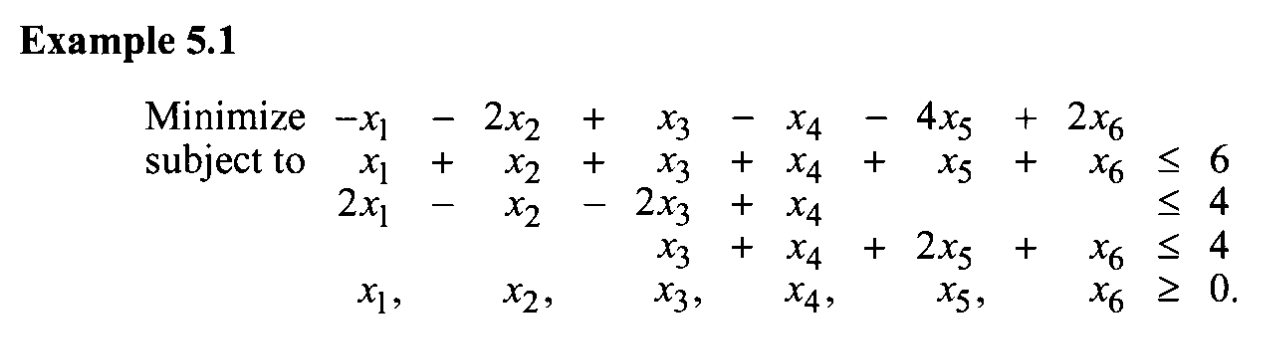


\textbf{Example 5.1: Minimize the following objective function subject to the constraints given:}

\begin{equation}
\text{Minimize} \quad -x_1 - 2x_2 + x_3 - x_4 - 4x_5 + 2x_6
\end{equation}

\textbf{Subject to:}
\begin{align*}
x_1 + x_2 + x_3 + x_4 + x_5 + x_6 & \leq 6, \\
2x_1 - x_2 - 2x_3 + x_4 & \leq 4, \\
x_3 + x_4 + 2x_5 + x_6 & \leq 4, \\
x_1, x_2, x_3, x_4, x_5, x_6 & \geq 0.
\end{align*}

In [9]:
from gurobipy import Model, GRB

# Create a new model
m = Model("example_5.1")

# Create variables
x1 = m.addVar(vtype=GRB.CONTINUOUS, lb=0, name="x1")
x2 = m.addVar(vtype=GRB.CONTINUOUS, lb=0,name="x2")
x3 = m.addVar(vtype=GRB.CONTINUOUS, lb=0,name="x3")
x4 = m.addVar(vtype=GRB.CONTINUOUS, lb=0,name="x4")
x5 = m.addVar(vtype=GRB.CONTINUOUS, lb=0,name="x5")
x6 = m.addVar(vtype=GRB.CONTINUOUS, lb=0,name="x6")

# Set the objective
m.setObjective(-x1 - 2*x2 + x3 - x4 - 4*x5 + 2*x6, GRB.MINIMIZE)

# Add constraints
m.addConstr(x1 + x2 + x3 + x4 + x5 + x6 <= 6, "c0")
m.addConstr(2*x1 - x2 - 2*x3 + x4 <= 4, "c1")
m.addConstr(x3 + x4 + 2*x5 + x6 <= 4, "c2")

# Integrate new variables
m.update()

# Solve the model
m.optimize()

# Print the solution
if m.status == GRB.Status.OPTIMAL:
    for v in m.getVars():
        print(f'{v.varName} = {v.x}')

    print(f'Obj: {m.objVal}')


Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1255U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 3 rows, 6 columns and 14 nonzeros
Model fingerprint: 0xd7b1ce29
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [1e+00, 4e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 6e+00]
Presolve removed 3 rows and 6 columns
Presolve time: 0.02s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -1.6000000e+01   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.03 seconds (0.00 work units)
Optimal objective -1.600000000e+01
x1 = 0.0
x2 = 4.0
x3 = 0.0
x4 = 0.0
x5 = 2.0
x6 = 0.0
Obj: -16.0


In [10]:
cbasis = tuple(m.getAttr('Vbasis', m.getVars()))
rbasis = tuple(m.getAttr('Cbasis', m.getConstrs()))
cbasis, rbasis

((-1, 0, -1, -1, 0, -1), (-1, 0, -1))